# Initial setups

mount google drive and authenticate to access files

In [1]:
#connect to runtime GPU
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


check the currect directory content

In [2]:
! ls
%cd ML-CWs

gdrive	sample_data
[Errno 2] No such file or directory: 'ML-CWs'
/content


change directory to specific dir

In [3]:
%cd gdrive/MyDrive/'Collaborate '

/content/gdrive/MyDrive/Collaborate 


install any package if missing

In [4]:
#! pip install <desired-python-library>

check the access of any file

# Tutorial: 9 convolutional network


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F


In [6]:
imdb = torch.load('charsdb.pth')
imdb['sets'].shape

torch.Size([29094])

In [7]:
from torch.utils.data import Dataset, DataLoader

import torchvision

torch.Size([770, 1, 32, 32])


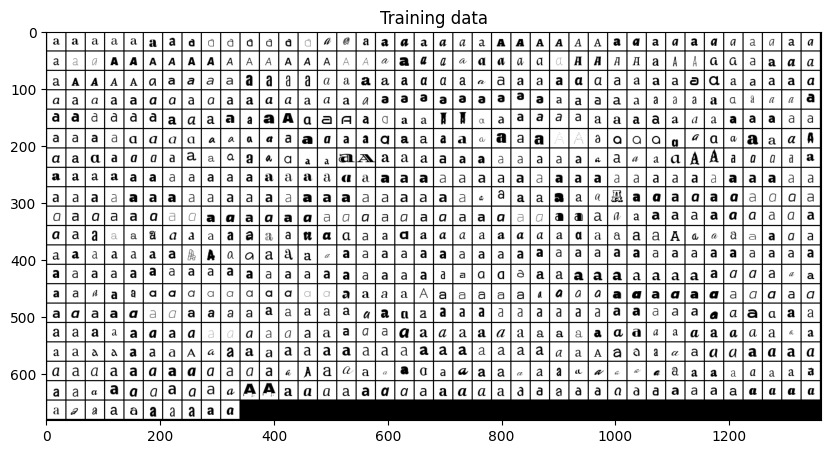

In [8]:
########################################################################################################################
## Making a grid plot of the training data for 'a'
########################################################################################################################

plt.figure(1,figsize=(10,10))
plt.clf()
plt.title('Training data')
sel=(imdb['sets']==0) & (imdb['labels']==0)

images_sel=(imdb['images'][sel,:,:,:])
print(images_sel.size())

tensor_grid=torchvision.utils.make_grid(images_sel,nrow=40)
image_grid=tensor_grid.permute(1,2,0)
plt.imshow(image_grid)

/tmp/ipykernel_731/3348860125.py:17: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  plt.figure(2,figsize=(5,5))


tensor([-0.2501], grad_fn=<ViewBackward0>)


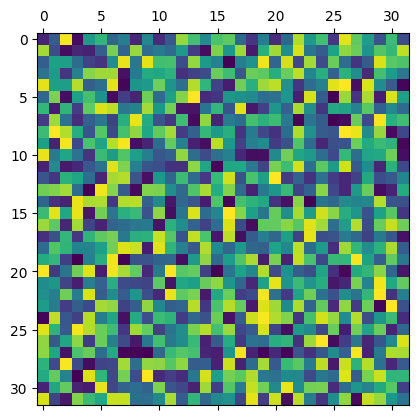

<Figure size 500x500 with 0 Axes>

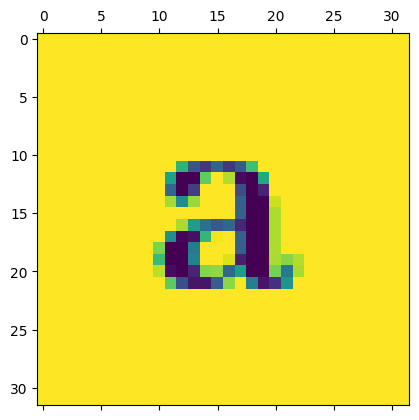

In [9]:
########################################################################################################################
## Build a fully connected layer with 32x32 input and 1 output
########################################################################################################################

# Initialize the layer and extract the weights
model=nn.Linear(32*32,1)
weight=model.weight

## Display the weights as an image
weight=weight.reshape(32,32).detach().numpy()
plt.figure(2,figsize=(5,5))
plt.matshow(weight);

# Transform a sample image into a flat array 32*32x1
sample_image=images_sel[0,:,:,:].squeeze()

plt.figure(2,figsize=(5,5))
plt.matshow(sample_image);

image_flatten=torch.flatten(sample_image)

# Apply the fully connected layer to the image
prediction=model(image_flatten)
print(prediction)

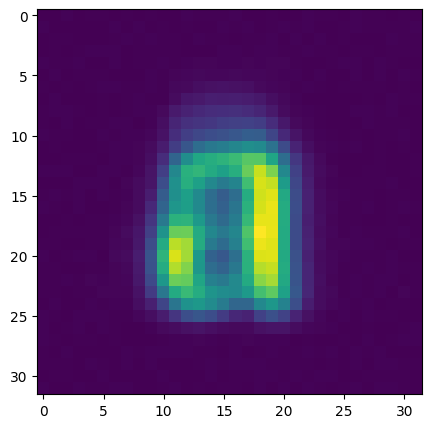

In [10]:
########################################################################################################################
## Make one step backpropagation
########################################################################################################################

# Define the optimization method
# SGD: Stochastic gradient descent
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

# Prepare all images to be processed by the fully connected neuron
image_view=torch.flatten(images_sel,1,3)
label=0
#print(image_view.size())

# Compute the output of all 'a'
prediction=model(image_view);

# Compute the difference between prediction and true label
loss=(prediction-label).sum()

# Compute the backward pass
loss.backward()

# Perform a step of optimization
optim.step()

# Show the updated weights
weight=model.weight.reshape(32,32).detach().numpy()

plt.figure(2,figsize=(5,5))
plt.imshow(weight);

torch.Size([5, 1, 28, 28])

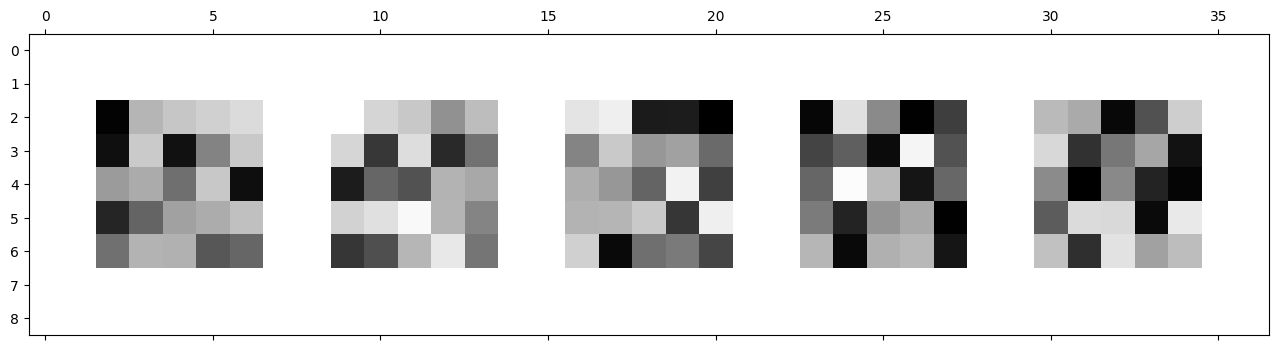

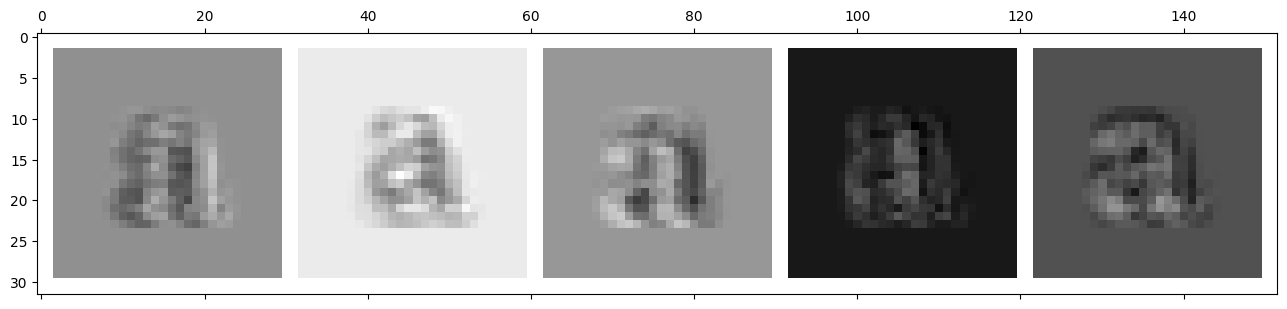

In [11]:
########################################################################################################################
## Build a convolutional layer with 5 filters, 5x5
########################################################################################################################

# Initialize the layer
model=nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)

#Extract and plot the weights
weight=model.weight.detach()

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

# Select an image to process and make it NxCxWxH
# with N number of images
# C number of channels
sample_image = images_sel[0,:,:,:].unsqueeze(0)
image_filtered=model(sample_image)
image_filtered=image_filtered.permute(1,0,2,3)

# plot resulting feature maps
tensor_grid=torchvision.utils.make_grid(image_filtered,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid)

image_filtered.size()

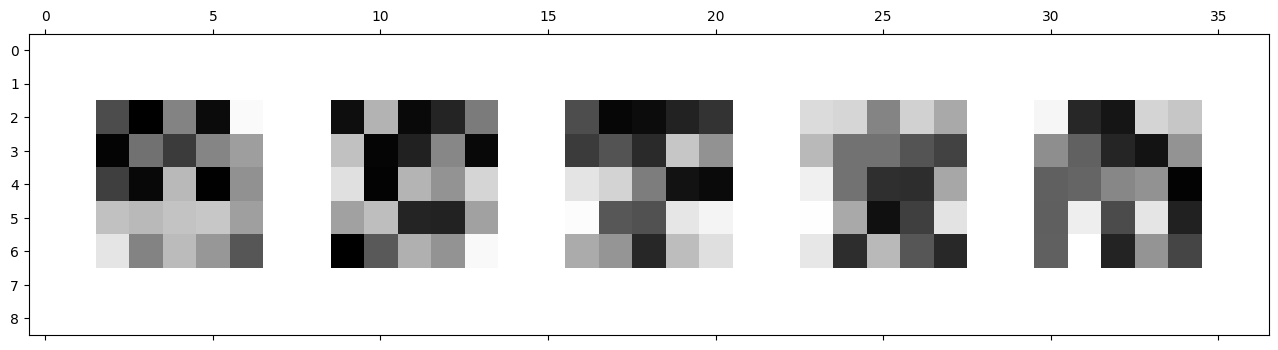

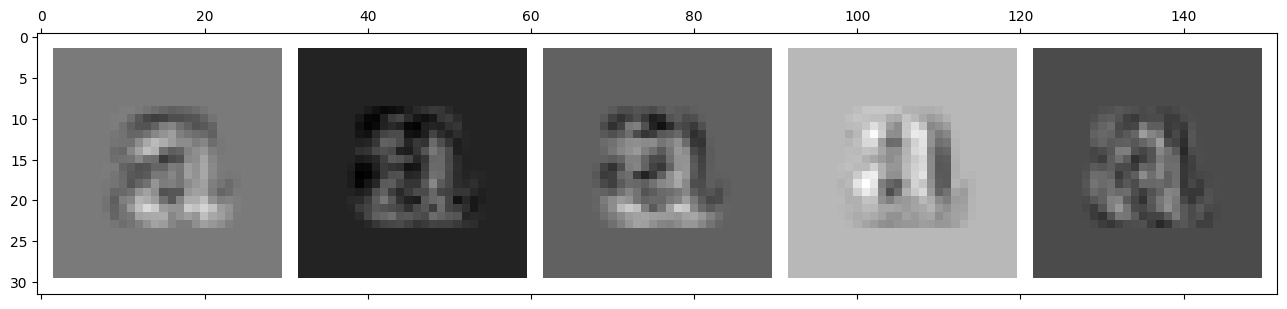

In [12]:
########################################################################################################################
## Build a small convolutional network
########################################################################################################################

# Define the model
class CNN_model(nn.Module):
    def __init__(self):
        super(CNN_model, self).__init__()

        self.layer_1 = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)
        self.layer_2 = nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, groups=5)
        self.layer_3=nn.Flatten(1,3)
        self.layer_4=nn.Linear(24*24*5,26)

    def forward(self,x):
        x1 = self.layer_1(x)
        x = nn.ReLU()(x1)
        x2 = self.layer_2(x)
        x = nn.ReLU()(x2)
        x = self.layer_3(x)
        x = nn.ReLU()(x)
        x = self.layer_4(x)

        return x, x1, x2

# Initialize the model
model=CNN_model()

# Display the filters of layer 1
weight=model.layer_1.weight

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

# Select an image to process and make it NxCxWxH and apply the network to the image
# with N number of images
# C number of channels
sample_image = images_sel[0,:,:,:].unsqueeze(0)
x,x1,x2=model(sample_image)

tensor_grid=torchvision.utils.make_grid(x1.permute(1,0,2,3),nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

using Kbest

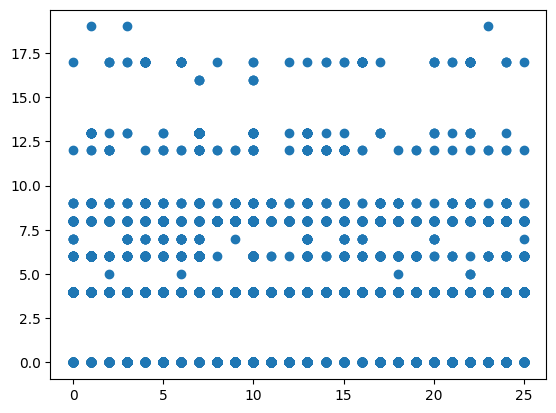

In [13]:
########################################################################################################################
## Make one step backpropagation
########################################################################################################################

# Define the optimization method
# SGD: Stochastic gradient descent
optim = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

loss_fun=nn.CrossEntropyLoss()

labels=imdb['labels']
inputs=imdb['images']

# Compute the output of all 'a'
prediction,x1,x2=model(inputs);
_, preds = torch.max(prediction, 1)

# Compute the difference between prediction and true label
#loss=((preds-labels)**2).sum()
loss=loss_fun(prediction,labels)

# Compute the backward pass
loss.backward()

# Perform a step of optimization
optim.step()

# Visializing the predictions
plt.plot(labels,preds.detach().numpy(),'o')

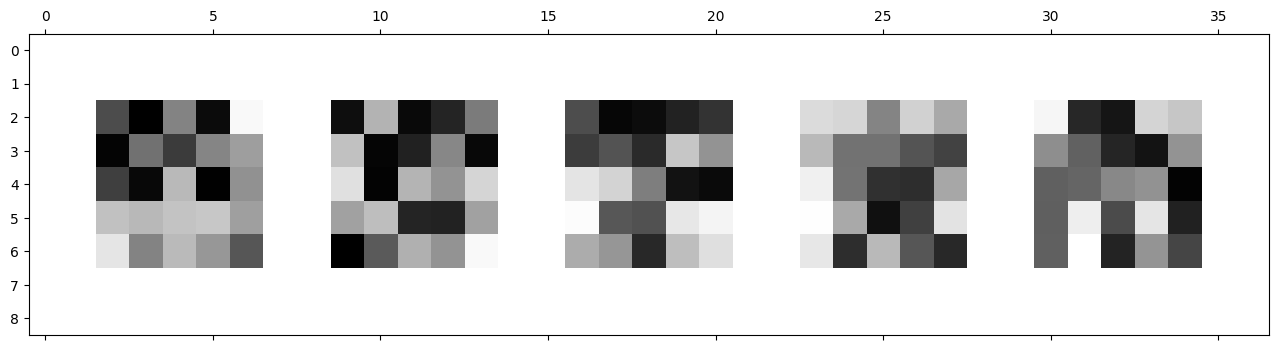

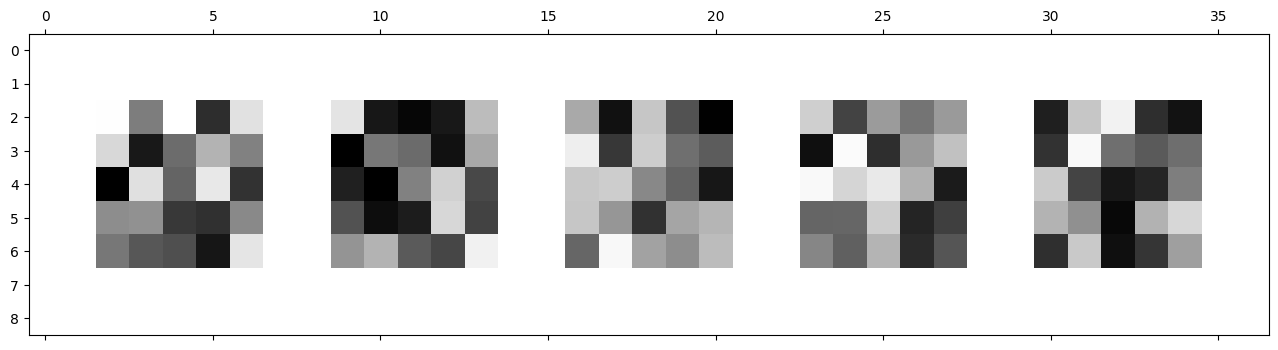

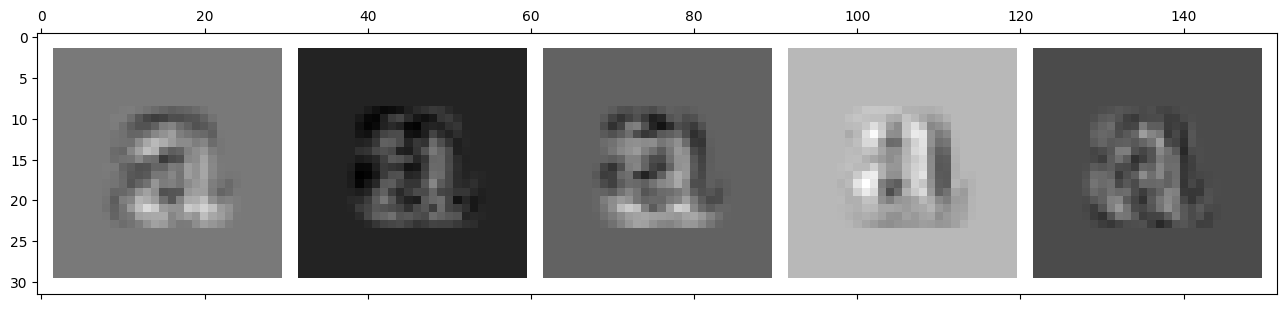

In [14]:
########################################################################################################################
## Visualizing updated weights
########################################################################################################################

weight=model.layer_1.weight

tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

weight=model.layer_2.weight
tensor_grid=torchvision.utils.make_grid(weight,nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

x,x1,x2=model(images_sel[0,:,:,:].unsqueeze(0))

tensor_grid=torchvision.utils.make_grid(x1.permute(1,0,2,3),nrow=5,normalize = True, pad_value=1)
image_grid=tensor_grid.permute(1,2,0)
plt.matshow(image_grid);

In [15]:
from sklearn.model_selection import train_test_split


In [16]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

# Splitting data into training and validation
Xtrain, Xvalid, Ytrain, Yvalid = train_test_split(
    imdb['images'],imdb['labels'],
    test_size=0.2,
    random_state=42,
)

#Defining the Dataset
class Char_Dataset(Dataset):
    def __init__(self,data,target,train:bool = True, transforms=None):
        self.data=data
        self.target=target
        self.train=train
        self.transforms=transforms

    def __getitem__(self,index):

        x=self.data[index,]

        if(self.train):
            if(self.transforms):
                x=self.transforms(x)


        if(self.train):
            # During training, for each image the Dataset returns
            #  - an image x
            #  - the true class y:
            y=self.target[index,]
            return x,y
        else:
            # During testing, only the image is returned
            return x

    def __len__(self):
        return len(self.target)

# Initializion datasets and dataloaders
batch_size = 500

train_dataset=Char_Dataset(
    data=Xtrain,
    target=Ytrain,
    train=True,
    transforms=None
)

valid_dataset=Char_Dataset(
    data=Xvalid,
    target=Yvalid,
    train=True,
    transforms=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    #num_workers=4,
    shuffle=False,
)

In [17]:
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################
datasets={'train':train_dataset,'valid':valid_dataset}
dataloaders={'train':train_loader,'valid':valid_loader}

optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
criterion = nn.CrossEntropyLoss()
num_epochs = 10

# if GPU is available, use it, otherwise use CPU
#device = torch.device("cuda")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
########################################################################################################################
## Building training and validation dataloaders
########################################################################################################################

for epoch in range(num_epochs):

    running_loss = 0.0
    running_corrects = 0.0

    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels=labels.to(device)

            # Zero out the grads
            optimizer.zero_grad()

            # Forward
            # Track history in train mode
            with torch.set_grad_enabled(phase == 'train'):
                model=model.to(device)
                outputs, x1, x2 = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels.type(torch.LongTensor).to(device))

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # Statistics
                running_loss += loss.item()*inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss/len(datasets[phase])
        epoch_acc = running_corrects.double()/len(datasets[phase])
        print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

train Loss: 2.2727 Acc: 0.4101
valid Loss: 11.0503 Acc: 2.1334
train Loss: 1.6243 Acc: 0.5706
valid Loss: 7.8061 Acc: 2.9259
train Loss: 1.6925 Acc: 0.5476
valid Loss: 8.5532 Acc: 2.6996
train Loss: 1.4335 Acc: 0.6176
valid Loss: 7.0061 Acc: 3.1572
train Loss: 1.0819 Acc: 0.7279
valid Loss: 5.4018 Acc: 3.6633
train Loss: 0.8189 Acc: 0.7951
valid Loss: 4.1822 Acc: 3.9816
train Loss: 0.7107 Acc: 0.8202
valid Loss: 3.6915 Acc: 4.0827
train Loss: 0.8779 Acc: 0.7670
valid Loss: 4.6852 Acc: 3.7656
train Loss: 0.7464 Acc: 0.8046
valid Loss: 3.8208 Acc: 4.0263
train Loss: 0.5752 Acc: 0.8516
valid Loss: 3.1110 Acc: 4.2212


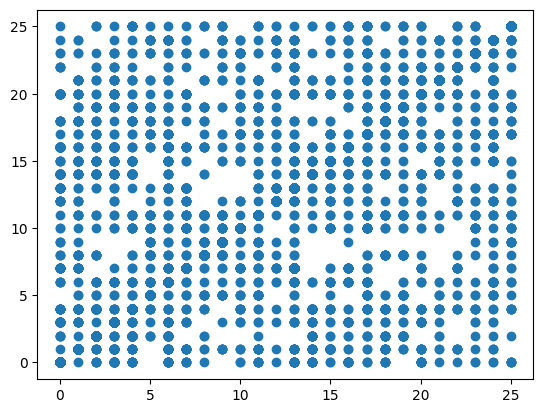

In [18]:
labels=imdb['labels']
inputs=imdb['images']

model=model.to(torch.device("cpu"))
# Compute the output of all 'a'
prediction,x1,x2=model(inputs);
_, preds = torch.max(prediction, 1)

# Visualizing the predictions
plt.plot(labels,preds.detach().numpy(),'o')